<a href="https://colab.research.google.com/github/adarsha4real/pytorch-basics/blob/main/foodvision_mini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### project Name: FoodVision mini


In [68]:
import torch
from torch import nn


In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Getting some data

In [70]:
import requests
import zipfile
from pathlib import Path

# setup path to a data folder

data_path = Path("data/")
image_path= data_path/"pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory already exist ......")
else:
  print(f"{image_path} doesnot exist, creating one....")
  image_path.mkdir(parents=True,exist_ok=True)


# download image from github

with open(data_path/"pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print(f"downloading pizza, steak, sushi data....")
  f.write(request.content)


# unzipping the images
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
  print(f"unzipping file.....")
  zip_ref.extractall(image_path)


data/pizza_steak_sushi directory already exist ......
downloading pizza, steak, sushi data....
unzipping file.....


In [71]:
data_path/"pizza_steak_sushi.zip"

PosixPath('data/pizza_steak_sushi.zip')

### data understanding and exploring

In [72]:
import os
def walk_through_dir(dir_path):
  """walks through dir_pathreturning its contents."""
  for dir_path,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dir_path}'")

In [73]:
walk_through_dir(image_path)

there are 2 directories and 0 images in 'data/pizza_steak_sushi'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
there are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
there are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
there are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
there are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
there are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
there are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'


In [74]:
image_path

PosixPath('data/pizza_steak_sushi')

In [75]:
train_dir = image_path/"train"
test_dir = image_path/"test"

data/pizza_steak_sushi/train/sushi/3004029.jpg
sushi
random image path : data/pizza_steak_sushi/train/sushi/3004029.jpg
random image class : sushi
random image size : (512, 512)
random image mode : RGB
random image format : JPEG
random image height : 512
random image width:512


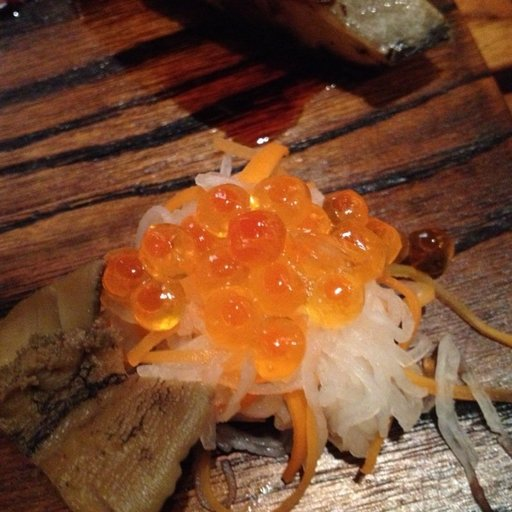

In [76]:
# visualize our data
import random
from PIL import Image

#set seed
random.seed(42)


# get all image path
image_path_list =list(image_path.glob("*/*/*.jpg"))
# pick a random image from image_path_list
random_image_path = random.choice(image_path_list)

print(random_image_path)

# get image class from path name( the image class is the name of the directory)
image_class= random_image_path.parent.stem
print(image_class)

# open image
img= Image.open(random_image_path)

# print metadata
print(f"random image path : {random_image_path}")
print(f"random image class : {image_class}")
print(f"random image size : {img.size}")
print(f"random image mode : {img.mode}")
print(f"random image format : {img.format}")
print(f"random image height : {img.height}")
print(f"random image width:{img.width}")
img


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

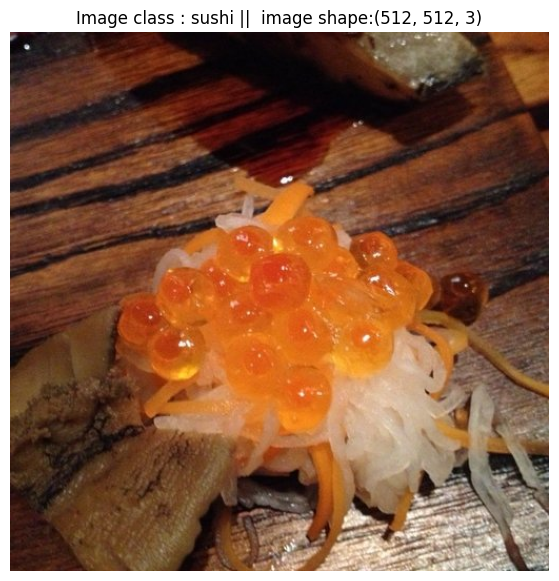

In [77]:
# visualize with matplotlib
import numpy as np
import matplotlib.pyplot as plt
#  turn the image into arrays of number
img_as_array = np.asarray(img)
# plot the image
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class : {image_class} ||  image shape:{img_as_array.shape}")
plt.axis(False)


Converting image into tensor

In [78]:
#  transforming data
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms

In [79]:
# transforming data with torchvision.transorms
data_transform = transforms.Compose([
    # resize or image to 64*64
    transforms.Resize(size=(64,64)),
    #flip the image horizontally at random
    transforms.RandomHorizontalFlip(p=0.5),
    # turn the mage into torch tensor
    transforms.ToTensor()

])

In [80]:
data_transform(img).dtype


torch.float32

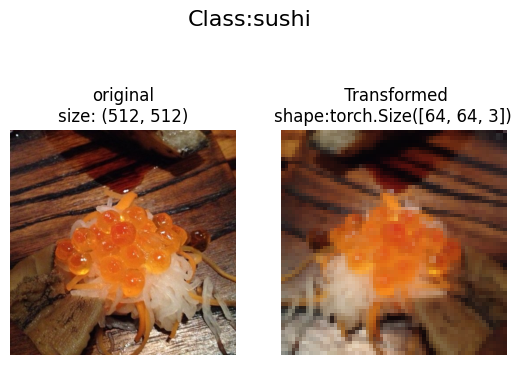

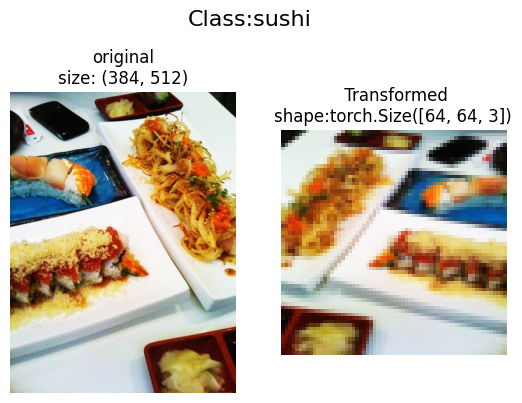

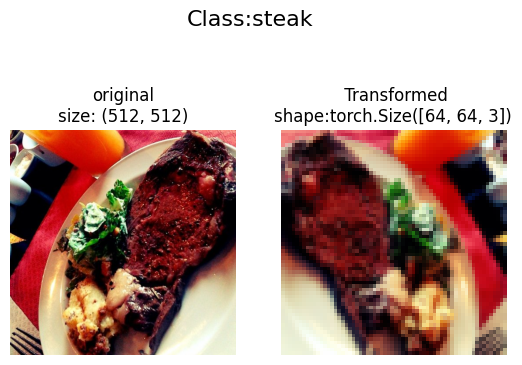

In [81]:
# visualzng data
def plot_transformed_images(image_paths:list,transform,n=3, seed = None) :
  if seed:
    random.seed(seed)
  random_image_paths= random.sample(image_paths,k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig,ax=plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"original\nsize: {f.size}")
      ax[0].axis(False)
      # transform and plot target image
      transformed_image = transform(f).permute(1,2,0) #note we will need to change shape for matplotlib
      ax[1].imshow(transformed_image)
      ax[1].set_title(f" Transformed\nshape:{transformed_image.shape}")
      ax[1].axis("off")


      fig.suptitle(f"Class:{image_path.parent.stem}",fontsize=16)




plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=42)


### loading image data with imagefolder
we can load image classification data using `torchvision.datasets.ImageFolder`

In [82]:
# use imagefoloder to create datasets
from torchvision import datasets
train_data= datasets.ImageFolder(root=train_dir,
                                 transform=data_transform,
                                 target_transform=None)
test_data= datasets.ImageFolder(root=test_dir,
                                transform= data_transform,
                                target_transform=None)



In [83]:
# get class name as list
class_names= train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [84]:
# class name as dict
class_dict= train_data.class_to_idx
class_dict



{'pizza': 0, 'steak': 1, 'sushi': 2}

In [85]:
img,label= train_data[0][0],train_data[0][1]
img.shape

torch.Size([3, 64, 64])

In [86]:
label

0

In [87]:
class_names[label]

'pizza'

In [88]:
# rearranging the order of dimension for visualization
img_permute=img.permute(1,2,0)

Text(0.5, 1.0, 'pizza')

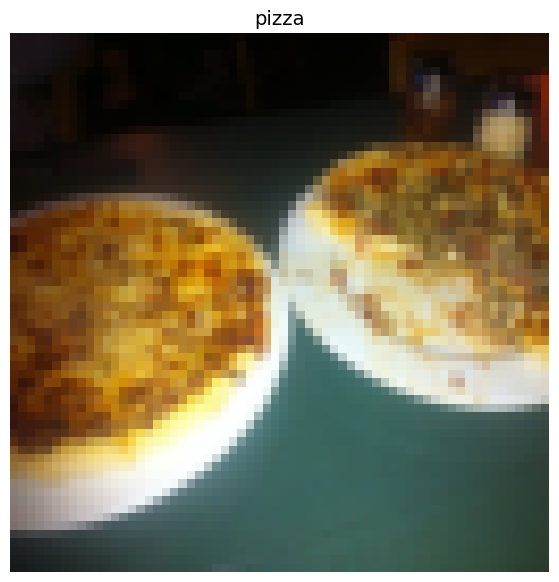

In [89]:
# visualization
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis("off")
plt.title(class_names[label],fontsize=14)

turn loaded images into `DataLoader`
but why dataloader??
A dataloader helps us turn datasets into iterable and we can customize the `batch size` so our model can see batch_size images at a time.

In [90]:
!nvidia-smi


Sat Aug  8 10:04:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [91]:
import os
os.cpu_count()

2

In [92]:
# turn train and test datasets into data_loader
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              num_workers=os.cpu_count(),
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=32,
                             num_workers=os.cpu_count(),
                             shuffle=False)

In [93]:
img,label=next(iter(train_dataloader))
print(f"image shape:{img.shape}")
print(f"label shape:{label.shape}")


image shape:torch.Size([32, 3, 64, 64])
label shape:torch.Size([32])


creating our own data loading custom datasets
*what we need?*


*  to be able to  load image from file
* to be able to get class name from the datasets
* to be able to get classes as dict from datasets





In [94]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List




In [95]:
#  instances of torchvision.datasets.ImageFolder()
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [99]:
# creating a helper function to get class name
# setup path for target directory
target_dir = train_dir
target_dir
# get the class names from the target dir
class_names_found = sorted([entry.name for entry in list (os.scandir(target_dir))])
class_names_found

['pizza', 'steak', 'sushi']

In [107]:
def find_classes(directory:str)->Tuple[list[str],Dict[str,int]]:
  classes= sorted(entry.name for entry in  os.scandir(directory) if entry.is_dir())
  if not classes:
    raise FileNotFoundError(f"couldn't find any classes in {directory}")
  # create a dictionary of index labels
  class_to_idx={class_name:i for i,class_name in enumerate(classes)}
  return classes , class_to_idx

In [109]:
find_classes(target_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

custom dataset calss

In [112]:
from torch.utils.data import Dataset
class ImageFolderCustom(Dataset):
  def __init__(self,targ_dir:str,transform=None):
    self.paths=list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    self.transform= transform
    self.classes,self.class_to_idx= find_classes(targ_dir)


  def load_image(self,index:int)-> Image.Image:
    image_path =   self.paths[index]
    return Image.open(image_path)


  def __len__(self)->int:
    return len(self.paths)

  def __getitem__(self, index:int) -> Tuple[torch.Tensor,int]:
    img=self.load_image(index)
    class_name= self.paths[index].parent.name
    class_idx=self.class_to_idx[class_name]

    if self.transform:
      return self.transform(img),class_idx
    else:
      return img,class_idx

In [113]:
# create a transform
from torchvision import transforms
train_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])
test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [114]:
train_data_custom = ImageFolderCustom(targ_dir=train_dir,
                                    transform=train_transforms)
test_data_custom = ImageFolderCustom(targ_dir=test_dir,
                                    transform=test_transforms)
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x7923e94b5310>,
 <__main__.ImageFolderCustom at 0x7923f0189a30>)

In [115]:
train_data_custom.classes

['pizza', 'steak', 'sushi']